# Why Subthreshold Noise Matters: Reproducing CMOS Inverter Physics
Author: Joshua JOHN
#### Reference
1. https://journals.aps.org/prx/pdf/10.1103/PhysRevX.11.031064


In [1]:
import yaml
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sse_core.compiler.parser import SSEParser
from sse_core.compiler.builder import SSECompiler
from sse_core.solvers.gillespie import GillespieSolver
from sse_core.solvers.export import TelemetryExporter

In [2]:
# --- 1. Define the 4 Physics Configurations ---
v_th = 0.026 # Thermal voltage at room temp
configs_fig11a = [
    {"vdd": 0.0,           "vin": 0.0},                  # Panel 1: Thermal equilibrium
    {"vdd": 5 * v_th,      "vin": 0.0},                  # Panel 2: Stretched NESS
    {"vdd": 5 * v_th,      "vin": -0.01 * (5 * v_th)},   # Panel 3: Slight bias
    {"vdd": 5 * v_th,      "vin": -0.2 * (5 * v_th)}     # Panel 4: Strong bias
]

results_files = []

base_yaml_str = """schema_version: "1.0.0"
simulation:
  solver: "gillespie"
  t_finish: 5.0e-7
  v_th: 0.023
  seed: 999
nodes:
  free:
    - name: "out"
  regulated:
    - name: "vdd"
      type: "constant"
      value: 0.
    - name: "vin"
      type: "constant"
      value: 0.005
    - name: "vss"
      type: "constant"
      value: -0.
components:
  - type: "capacitor"
    name: "C_gate_p"
    terminals: ["vin", "out"]
    specs: {capacitance: 5.0e-17}
  - type: "capacitor"
    name: "C_gate_n"
    terminals: ["vin", "out"]
    specs: {capacitance: 5.0e-17}
  - type: "capacitor"
    name: "C_out_p"
    terminals: ["vdd", "out"] 
    specs: {capacitance: 5.0e-17}
  - type: "capacitor"
    name: "C_out_n"
    terminals: ["out", "vss"]
    specs: {capacitance: 5.0e-17}
  - type: "p_channel_mosfet"
    name: "M_pullup"
    terminals: {drain: "out", gate: "vin", source: "vdd", bulk: "vdd"}
    specs: {I0: 1.6e-7, VT: -0.0, n: 1.0}
  - type: "n_channel_mosfet"
    name: "M_pulldown"
    terminals: {drain: "out", gate: "vin", source: "vss", bulk: "vss"}
    specs: {I0: 1.6e-7, VT: 0.0, n: 1.0}
"""  


In [3]:
# --- 2. Robust Simulation Loop ---
for i, cfg in enumerate(configs_fig11a):
    # Safely modify the YAML AST
    yaml_dict = yaml.safe_load(base_yaml_str)
    
    # Update regulated nodes dynamically
    for node in yaml_dict['nodes']['regulated']:
        if node['name'] == 'vdd':
            node['value'] = cfg['vdd']
        elif node['name'] == 'vss':
            node['value'] = -cfg['vdd']  # Vss is symmetric to Vdd
        elif node['name'] == 'vin':
            node['value'] = cfg['vin']
            
    updated_yaml_str = yaml.dump(yaml_dict)
    
    # Compile
    assembly = SSECompiler.compile_string(updated_yaml_str)
    parsed_netlist = SSEParser.parse_string(updated_yaml_str)
    
    # Dynamically extract vr array based on assembly's expected order
    vr_dict = {node.name: node.value for node in parsed_netlist.nodes.regulated}
    vr = np.array([vr_dict[name] for name in assembly.regulated_names], dtype=np.float64)
    
    # Simulate
    solver = GillespieSolver(parsed_netlist, assembly)
    q_init = np.zeros(len(assembly.free_names)) # Start at 0 charge
    
    print(f"Running Config {i+1}/4: Vdd={cfg['vdd']:.3f}, Vin={cfg['vin']:.4f}...")
    history = solver.simulate(q_init, vr, max_steps=500000) # Increased steps for smooth tails
    
    # Export
    filename = f"fig11a_panel_{i+1}.h5"
    TelemetryExporter.export_to_hdf5(filename, history, assembly, v_th=v_th)
    results_files.append((filename, cfg))

Running Config 1/4: Vdd=0.000, Vin=0.0000...
Running Config 2/4: Vdd=0.130, Vin=0.0000...
Running Config 3/4: Vdd=0.130, Vin=-0.0013...
Running Config 4/4: Vdd=0.130, Vin=-0.0260...


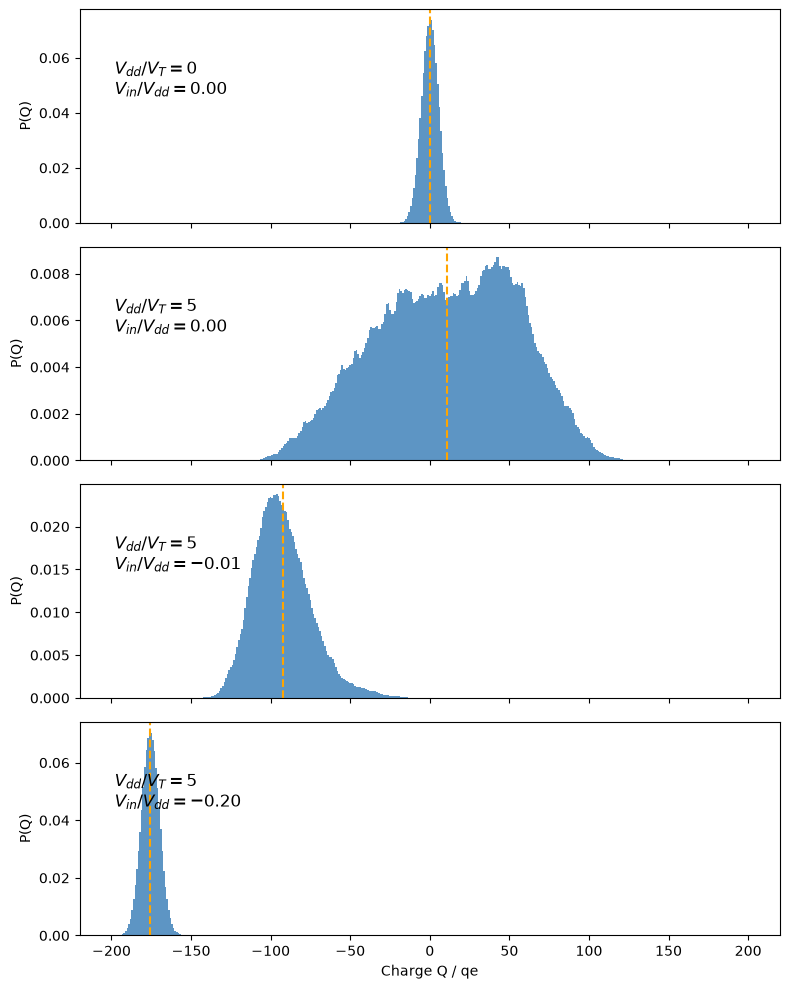

In [8]:
# --- 3. Publication-Quality Plotting ---
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

for i, (filename, cfg) in enumerate(results_files):
    ax = axes[i]
    with h5py.File(filename, 'r') as h5f:
        q_raw = h5f['data/charges'][:, 0] # Assuming 'out' is index 0
        
        # Trim the first 0.2% to remove the transient "burn-in" fall
        burn_in_idx = int(len(q_raw) * 0.002)
        q_steady = q_raw[burn_in_idx:]
        
        # 1. Find the min and max of your steady-state charge
        q_min, q_max = np.min(q_steady), np.max(q_steady)

        # 2. Create bin edges that sit exactly at +/- 0.5 around the integers
        integer_bins = np.arange(q_min - 0.5, q_max + 1.5, 1)

        # 3. Plot with the explicit bins
        ax.hist(q_steady, bins=integer_bins, density=True, 
                histtype='stepfilled', color='#5d95c4', alpha=1.0, edgecolor='none')
        
        #ax.set_yscale('log')
        
        # Dynamic label text matching the paper
        vdd_ratio = cfg['vdd'] / v_th if v_th != 0 else 0
        vin_ratio = cfg['vin'] / cfg['vdd'] if cfg['vdd'] != 0 else 0
        label_text = f"$V_{{dd}}/V_T = {vdd_ratio:.0f}$\n$V_{{in}}/V_{{dd}} = {vin_ratio:.2f}$"
        ax.text(0.05, 0.6, label_text, transform=ax.transAxes, fontsize=12)
        
        # Add visual mean line
        ax.axvline(x=np.mean(q_steady), color='orange', linestyle='--', linewidth=1.5)
        
        #ax.set_ylim(1e-6, 0.2)
        ax.set_ylabel('P(Q)')

axes[-1].set_xlabel('Charge Q / qe')
axes[-1].set_xlim(-220, 220) # Adjust based on your C_o scaling to frame it perfectly
plt.tight_layout()
plt.show()